In [1]:
import numpy as np
import pandas as pd

In [2]:
from sklearn.datasets import load_iris
iris=load_iris()

In [3]:
type(iris)

sklearn.utils._bunch.Bunch

In [4]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [5]:
X=iris.data
y=iris.target

In [6]:
X.shape

(150, 4)

In [7]:
y.shape

(150,)

In [8]:
df=pd.DataFrame(X, columns=iris.feature_names)
df["species"]=y

In [9]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [10]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [11]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [12]:
df[["species"]].value_counts()

species
0          50
1          50
2          50
Name: count, dtype: int64

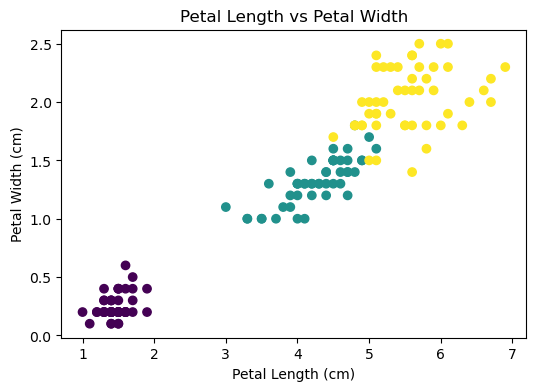

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

scatter=plt.scatter(
    df["petal length (cm)"],
    df["petal width (cm)"],
    c=df["species"]
)

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Petal Length vs Petal Width")

plt.show()

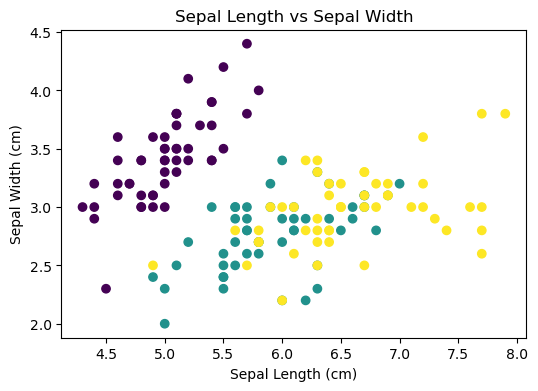

In [14]:
plt.figure(figsize=(6,4))

plt.scatter(
    df["sepal length (cm)"],
    df["sepal width (cm)"],
    c=df["species"]
)

plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("Sepal Length vs Sepal Width")

plt.show()

In [15]:
from sklearn.model_selection import train_test_split

X=df.drop(columns=["species"])
y=df["species"]

X_train, X_test, y_train, y_test=train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn=KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred=knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [17]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [20]:
X_train_scaled.mean(axis=0)

array([-1.20829273e-15, -2.03679666e-15,  4.99600361e-16,  1.67458640e-15])

In [21]:
X_train_scaled.std(axis=0)

array([1., 1., 1., 1.])

In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

for k in [1, 3, 5, 7, 15]:
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds=knn.predict(X_test)
    acc=accuracy_score(y_test, preds)
    print("k=", k, ", accuracy=", acc)

k= 1 , accuracy= 0.9666666666666667
k= 3 , accuracy= 1.0
k= 5 , accuracy= 1.0
k= 7 , accuracy= 0.9666666666666667
k= 15 , accuracy= 0.9666666666666667
